# Sales Data Analysis

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

In [60]:
df = pd.read_csv("/content/sales_data.csv")

In [61]:
df

,CustomerID,Region,Sales,Discount,Date,ProductID,Quantity,Return,CustomerType,SalesChannel,PaymentMethod,SatisfactionScore,ProductCategory
0,1001,East,21708.779879,NaN,2024-02-27 03:21:48.108108104,164,16,0,VIP,Online,Credit Card,3,Electronics
1,1002,West,29380.854196,5.0,2024-05-09 22:40:43.243243240,156,22,0,New,In-Store,Bank Transfer,6,Sports
2,1003,North,24752.119191,15.0,2024-05-01 00:05:45.945945944,192,85,0,New,In-Store,Credit Card,2,Health & Beauty
3,1004,East,17115.481722,5.0,2024-08-25 20:59:49.189189184,198,54,0,Returning,Direct,Cash,10,Sports
4,1005,East,15507.926643,NaN,2024-05-31 15:48:28.108108104,139,21,0,New,In-Store,Credit Card,1,Sports
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1996,North,17560.442959,15.0,2024-04-18 20:52:36.756756752,177,22,0,Returning,In-Store,Credit Card,5,Clothing
996,1997,North,30786.541066,NaN,2023-08-01 00:40:21.621621620,156,13,0,Returning,In-Store,Credit Card,10,Electronics
997,1998,West,16971.425385,15.0,2023-09-10 21:37:17.837837836,146,89,0,Returning,Online,Credit Card,9,Toys
998,1999,West,23710.476860,NaN,2023-07-08 09:33:41.621621620,199,48,0,VIP,In-Store,Bank Transfer,4,Home & Kitchen


# Initial Data Inspection

In [62]:
df.shape

(1000, 13)

In [63]:
df.columns

Index(['CustomerID', 'Region', 'Sales', 'Discount', 'Date', 'ProductID',
       'Quantity', 'Return', 'CustomerType', 'SalesChannel', 'PaymentMethod',
       'SatisfactionScore', 'ProductCategory'],
      dtype='object')

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         1000 non-null   int64  
 1   Region             970 non-null    object 
 2   Sales              950 non-null    float64
 3   Discount           723 non-null    float64
 4   Date               1000 non-null   object 
 5   ProductID          1000 non-null   int64  
 6   Quantity           1000 non-null   int64  
 7   Return             1000 non-null   int64  
 8   CustomerType       1000 non-null   object 
 9   SalesChannel       1000 non-null   object 
 10  PaymentMethod      1000 non-null   object 
 11  SatisfactionScore  1000 non-null   int64  
 12  ProductCategory    1000 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 101.7+ KB


In [65]:
df.describe(include="all")

,CustomerID,Region,Sales,Discount,Date,ProductID,Quantity,Return,CustomerType,SalesChannel,PaymentMethod,SatisfactionScore,ProductCategory
count,1000.000000,970,950.000000,723.000000,1000,1000.00000,1000.000000,1000.000000,1000,1000,1000,1000.000000,1000
unique,NaN,4,NaN,NaN,637,NaN,NaN,NaN,3,3,3,NaN,7
top,NaN,West,NaN,NaN,2024-07-07 16:47:34.054054048,NaN,NaN,NaN,Returning,In-Store,Bank Transfer,NaN,Books
freq,NaN,269,NaN,NaN,5,NaN,NaN,NaN,365,339,345,NaN,160
mean,1500.500000,NaN,20241.792218,10.000000,NaN,149.45100,50.321000,0.091000,NaN,NaN,NaN,5.559000,NaN
std,288.819436,NaN,5043.372428,4.076825,NaN,28.34221,27.920557,0.287753,NaN,NaN,NaN,3.004921,NaN
min,1001.000000,NaN,5518.723109,5.000000,NaN,100.00000,1.000000,0.000000,NaN,NaN,NaN,1.000000,NaN
25%,1250.750000,NaN,16866.920156,5.000000,NaN,126.00000,27.000000,0.000000,NaN,NaN,NaN,3.000000,NaN
50%,1500.500000,NaN,20233.542855,10.000000,NaN,148.00000,51.000000,0.000000,NaN,NaN,NaN,6.000000,NaN
75%,1750.250000,NaN,23488.595382,15.000000,NaN,174.00000,74.000000,0.000000,NaN,NaN,NaN,8.000000,NaN


# Data Cleaning

In [66]:
df.isnull().sum()

,0
CustomerID,0
Region,30
Sales,50
Discount,277
Date,0
ProductID,0
Quantity,0
Return,0
CustomerType,0
SalesChannel,0


In [67]:
df.dtypes

,0
CustomerID,int64
Region,object
Sales,float64
Discount,float64
Date,object
ProductID,int64
Quantity,int64
Return,int64
CustomerType,object
SalesChannel,object


In [68]:
df.head()

,CustomerID,Region,Sales,Discount,Date,ProductID,Quantity,Return,CustomerType,SalesChannel,PaymentMethod,SatisfactionScore,ProductCategory
0,1001,East,21708.779879,NaN,2024-02-27 03:21:48.108108104,164,16,0,VIP,Online,Credit Card,3,Electronics
1,1002,West,29380.854196,5.0,2024-05-09 22:40:43.243243240,156,22,0,New,In-Store,Bank Transfer,6,Sports
2,1003,North,24752.119191,15.0,2024-05-01 00:05:45.945945944,192,85,0,New,In-Store,Credit Card,2,Health & Beauty
3,1004,East,17115.481722,5.0,2024-08-25 20:59:49.189189184,198,54,0,Returning,Direct,Cash,10,Sports
4,1005,East,15507.926643,NaN,2024-05-31 15:48:28.108108104,139,21,0,New,In-Store,Credit Card,1,Sports


In [69]:
df['Sales'] = df['Sales'].fillna(0).astype(int)
df['Discount'] = df['Discount'].fillna(0).astype(int)

In [70]:
df.dtypes

,0
CustomerID,int64
Region,object
Sales,int64
Discount,int64
Date,object
ProductID,int64
Quantity,int64
Return,int64
CustomerType,object
SalesChannel,object


In [71]:
df['Sales'].fillna(df['Sales'].median(), inplace = True)

/tmp/ipykernel_9798/2223880152.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sales'].fillna(df['Sales'].median(), inplace = True)


In [72]:
df.isnull().sum()

,0
CustomerID,0
Region,30
Sales,0
Discount,0
Date,0
ProductID,0
Quantity,0
Return,0
CustomerType,0
SalesChannel,0


In [73]:
df['Region'] = df['Region'].fillna(df['Region'].mode()[0])

In [74]:
df.isnull().sum()

,0
CustomerID,0
Region,0
Sales,0
Discount,0
Date,0
ProductID,0
Quantity,0
Return,0
CustomerType,0
SalesChannel,0


In [75]:
df.head()

,CustomerID,Region,Sales,Discount,Date,ProductID,Quantity,Return,CustomerType,SalesChannel,PaymentMethod,SatisfactionScore,ProductCategory
0,1001,East,21708,0,2024-02-27 03:21:48.108108104,164,16,0,VIP,Online,Credit Card,3,Electronics
1,1002,West,29380,5,2024-05-09 22:40:43.243243240,156,22,0,New,In-Store,Bank Transfer,6,Sports
2,1003,North,24752,15,2024-05-01 00:05:45.945945944,192,85,0,New,In-Store,Credit Card,2,Health & Beauty
3,1004,East,17115,5,2024-08-25 20:59:49.189189184,198,54,0,Returning,Direct,Cash,10,Sports
4,1005,East,15507,0,2024-05-31 15:48:28.108108104,139,21,0,New,In-Store,Credit Card,1,Sports


In [76]:
df.drop(columns=['Date'], inplace = True)
df.drop(columns=['SatisfactionScore'], inplace = True)

In [77]:
df.head()

,CustomerID,Region,Sales,Discount,ProductID,Quantity,Return,CustomerType,SalesChannel,PaymentMethod,ProductCategory
0,1001,East,21708,0,164,16,0,VIP,Online,Credit Card,Electronics
1,1002,West,29380,5,156,22,0,New,In-Store,Bank Transfer,Sports
2,1003,North,24752,15,192,85,0,New,In-Store,Credit Card,Health & Beauty
3,1004,East,17115,5,198,54,0,Returning,Direct,Cash,Sports
4,1005,East,15507,0,139,21,0,New,In-Store,Credit Card,Sports


In [78]:
df.duplicated().sum()

np.int64(0)

In [79]:
df.rename(columns={'PaymentMethod': 'PaymentType'}, inplace = True)

In [80]:
df

,CustomerID,Region,Sales,Discount,ProductID,Quantity,Return,CustomerType,SalesChannel,PaymentType,ProductCategory
0,1001,East,21708,0,164,16,0,VIP,Online,Credit Card,Electronics
1,1002,West,29380,5,156,22,0,New,In-Store,Bank Transfer,Sports
2,1003,North,24752,15,192,85,0,New,In-Store,Credit Card,Health & Beauty
3,1004,East,17115,5,198,54,0,Returning,Direct,Cash,Sports
4,1005,East,15507,0,139,21,0,New,In-Store,Credit Card,Sports
...,...,...,...,...,...,...,...,...,...,...,...
995,1996,North,17560,15,177,22,0,Returning,In-Store,Credit Card,Clothing
996,1997,North,30786,0,156,13,0,Returning,In-Store,Credit Card,Electronics
997,1998,West,16971,15,146,89,0,Returning,Online,Credit Card,Toys
998,1999,West,23710,0,199,48,0,VIP,In-Store,Bank Transfer,Home & Kitchen


In [81]:
df.drop(columns=['ProductID'], inplace = True)
df.drop(columns=['Return'], inplace = True)

In [82]:
df

,CustomerID,Region,Sales,Discount,Quantity,CustomerType,SalesChannel,PaymentType,ProductCategory
0,1001,East,21708,0,16,VIP,Online,Credit Card,Electronics
1,1002,West,29380,5,22,New,In-Store,Bank Transfer,Sports
2,1003,North,24752,15,85,New,In-Store,Credit Card,Health & Beauty
3,1004,East,17115,5,54,Returning,Direct,Cash,Sports
4,1005,East,15507,0,21,New,In-Store,Credit Card,Sports
...,...,...,...,...,...,...,...,...,...
995,1996,North,17560,15,22,Returning,In-Store,Credit Card,Clothing
996,1997,North,30786,0,13,Returning,In-Store,Credit Card,Electronics
997,1998,West,16971,15,89,Returning,Online,Credit Card,Toys
998,1999,West,23710,0,48,VIP,In-Store,Bank Transfer,Home & Kitchen


In [83]:
df.columns

Index(['CustomerID', 'Region', 'Sales', 'Discount', 'Quantity', 'CustomerType',
       'SalesChannel', 'PaymentType', 'ProductCategory'],
      dtype='object')

In [84]:
df.shape

(1000, 9)

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomerID       1000 non-null   int64 
 1   Region           1000 non-null   object
 2   Sales            1000 non-null   int64 
 3   Discount         1000 non-null   int64 
 4   Quantity         1000 non-null   int64 
 5   CustomerType     1000 non-null   object
 6   SalesChannel     1000 non-null   object
 7   PaymentType      1000 non-null   object
 8   ProductCategory  1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 70.4+ KB


In [86]:
df.describe(include='all')

,CustomerID,Region,Sales,Discount,Quantity,CustomerType,SalesChannel,PaymentType,ProductCategory
count,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000,1000,1000,1000
unique,NaN,4,NaN,NaN,NaN,3,3,3,7
top,NaN,West,NaN,NaN,NaN,Returning,In-Store,Bank Transfer,Books
freq,NaN,299,NaN,NaN,NaN,365,339,345,160
mean,1500.500000,NaN,19229.235000,7.230000,50.321000,NaN,NaN,NaN,NaN
std,288.819436,NaN,6606.290411,5.662081,27.920557,NaN,NaN,NaN,NaN
min,1001.000000,NaN,0.000000,0.000000,1.000000,NaN,NaN,NaN,NaN
25%,1250.750000,NaN,16229.500000,0.000000,27.000000,NaN,NaN,NaN,NaN
50%,1500.500000,NaN,19878.500000,5.000000,51.000000,NaN,NaN,NaN,NaN
75%,1750.250000,NaN,23229.000000,10.000000,74.000000,NaN,NaN,NaN,NaN


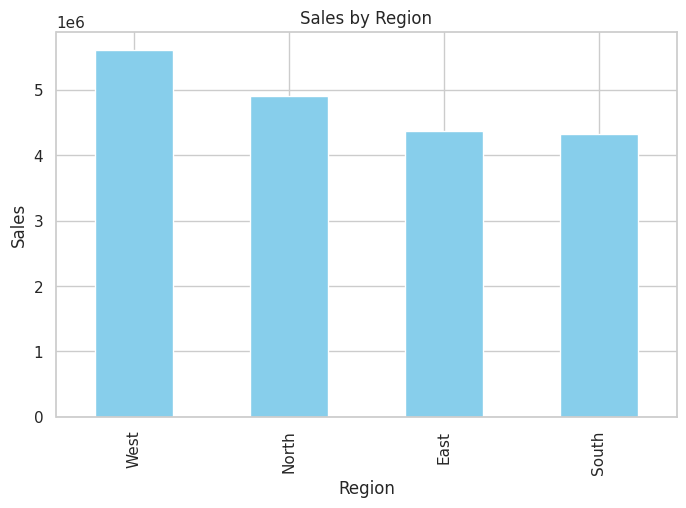

In [96]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales.plot(kind='bar', figsize=(8,5), color='skyblue')
plt.title('Sales by Region')
plt.ylabel('Sales')
plt.show()

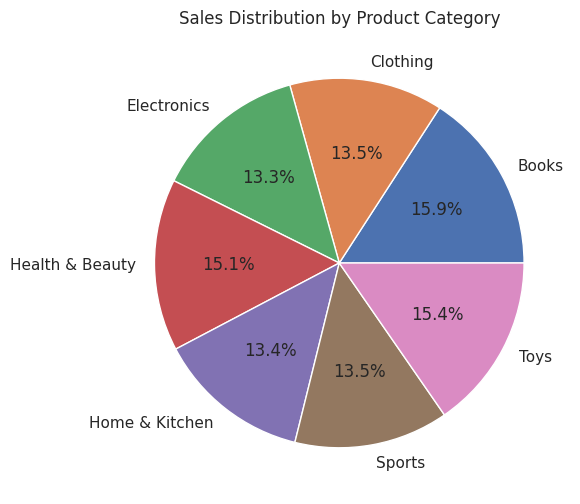

In [97]:
category_sales = df.groupby('ProductCategory')['Sales'].sum()
category_sales.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title('Sales Distribution by Product Category')
plt.ylabel('')
plt.show()

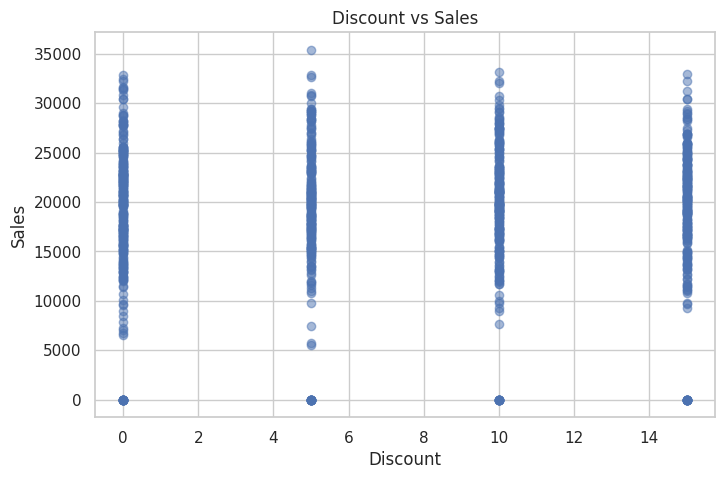

In [98]:
plt.figure(figsize=(8,5))
plt.scatter(df['Discount'], df['Sales'], alpha=0.5)
plt.title('Discount vs Sales')
plt.xlabel('Discount')
plt.ylabel('Sales')
plt.show()

In [99]:
df.head()

,CustomerID,Region,Sales,Discount,Quantity,CustomerType,SalesChannel,PaymentType,ProductCategory,Month
0,1001,East,21708,0,16,VIP,Online,Credit Card,Electronics,2026-02
1,1002,West,29380,5,22,New,In-Store,Bank Transfer,Sports,2026-03
2,1003,North,24752,15,85,New,In-Store,Credit Card,Health & Beauty,2026-02
3,1004,East,17115,5,54,Returning,Direct,Cash,Sports,2026-03
4,1005,East,15507,0,21,New,In-Store,Credit Card,Sports,2026-02


In [101]:
df.drop(columns=['Month'], inplace=True)

In [102]:
df.head()

,CustomerID,Region,Sales,Discount,Quantity,CustomerType,SalesChannel,PaymentType,ProductCategory
0,1001,East,21708,0,16,VIP,Online,Credit Card,Electronics
1,1002,West,29380,5,22,New,In-Store,Bank Transfer,Sports
2,1003,North,24752,15,85,New,In-Store,Credit Card,Health & Beauty
3,1004,East,17115,5,54,Returning,Direct,Cash,Sports
4,1005,East,15507,0,21,New,In-Store,Credit Card,Sports


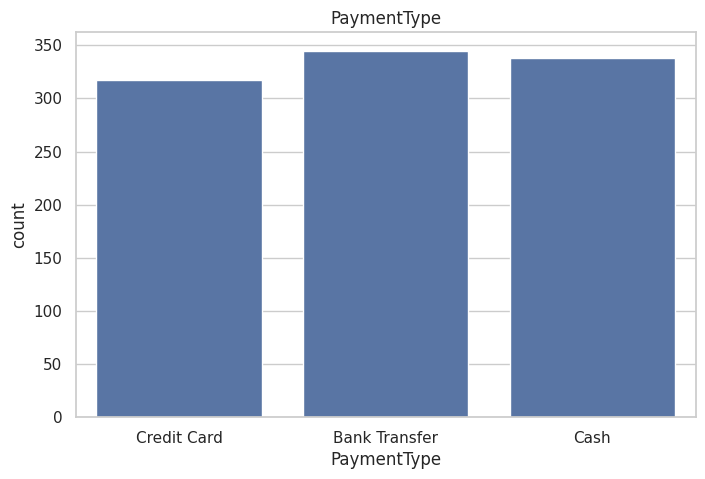

In [103]:
sns.countplot(x='PaymentType', data=df)
plt.title("PaymentType")
plt.show()


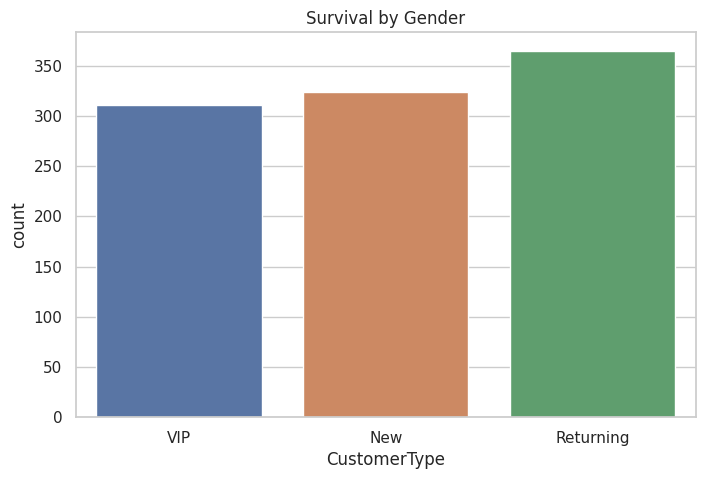

In [105]:
sns.countplot(x='CustomerType', hue='CustomerType', data=df)
plt.title("Survival by Gender")
plt.show()

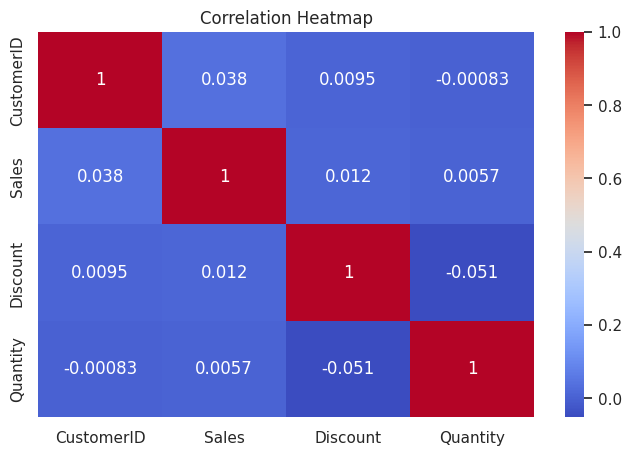

In [106]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

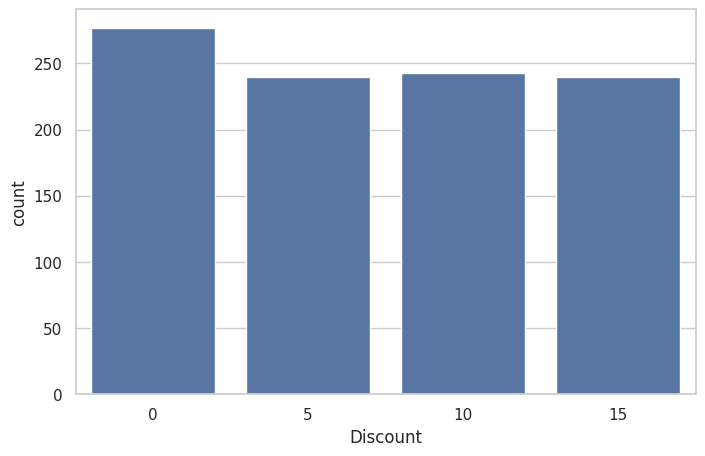

In [114]:
sns.countplot(x='Discount', data=df)
plt.show()